<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/02_Cria%C3%A7%C3%A3o_Target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Criação de Target - Bom e Mau pagador**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from pathlib import Path
import os

# 1. Tentar conectar ao Google Drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print("Aviso: Não foi possível montar o Google Drive automaticamente. Prosseguindo...")

# Caminho do Google Drive definido no Notebook 01
PROCESSED_DIR = Path('/content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed')
INPUT_PATH_CADASTRO = PROCESSED_DIR / 'application_record_tratado.parquet'
INPUT_PATH_CREDITO = PROCESSED_DIR / 'credit_record_tratado.parquet'

# 2. Carregar as bases
path_cad = Path('/content/application_record.csv')
path_cred = Path('/content/credit_record.csv')

if path_cad.exists() and path_cred.exists():
    print("✅ CSVs locais detectados na raiz '/content/'. Carregando e tratando os dados...")
    df_cadastro = pd.read_csv(path_cad)
    df_credito = pd.read_csv(path_cred)

    # Aplicar tratamentos equivalentes
    df_cadastro['Idade'] = (-df_cadastro['DAYS_BIRTH'] / 365.25).astype(int)
    df_cadastro['Anos_Trabalhados'] = df_cadastro['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else -x / 365.25)
    df_cadastro['CNT_FAM_MEMBERS_TRATADO'] = df_cadastro['CNT_FAM_MEMBERS'].clip(upper=5)

    # Como os parquets não estavam no Drive, vamos criá-los agora para sincronizar o Drive de forma definitiva!
    try:
        PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
        df_cadastro.to_parquet(INPUT_PATH_CADASTRO, index=False)
        df_credito.to_parquet(INPUT_PATH_CREDITO, index=False)
        print(f"✅ Excelente! Arquivos salvos e sincronizados com sucesso no seu Drive em:\n -> {PROCESSED_DIR}")
    except Exception as e:
        print(f"⚠️ Aviso: Não foi possível salvar os parquets de volta no Drive ({e}). Mas a execução continuará normalmente usando as bases locais.")

elif INPUT_PATH_CADASTRO.exists() and INPUT_PATH_CREDITO.exists():
    df_cadastro = pd.read_parquet(INPUT_PATH_CADASTRO)
    df_credito = pd.read_parquet(INPUT_PATH_CREDITO)
    print("✅ Bases carregadas diretamente do Google Drive (Parquet) com sucesso!")
else:
    raise FileNotFoundError(
        "\n❌ ERRO: Não foi possível encontrar as bases em nenhuma das origens!\n"
        "Por favor, certifique-se de fazer o upload dos arquivos 'application_record.csv' e 'credit_record.csv' para a raiz do Colab (pasta '/content/')."
    )

# Definir variáveis globais necessárias para as células seguintes do Notebook 02
df_excel = df_cadastro.copy()  # Usado na célula 4eab1adf
target = 'MAU_PAGADOR'          # Usado na célula 4a7c9754

print(f"\nShape df_cadastro (df_excel): {df_cadastro.shape}")
print(f"Shape df_credito: {df_credito.shape}")

Mounted at /content/drive
✅ CSVs locais detectados na raiz '/content/'. Carregando e tratando os dados...
✅ Excelente! Arquivos salvos e sincronizados com sucesso no seu Drive em:
 -> /content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed

Shape df_cadastro (df_excel): (438557, 21)
Shape df_credito: (1048575, 3)


 ## **Definição de"Mau pagador" e "Bom pagador"**

Criamos um DataFrame por "ID"` contendo a classificação de risco (Target) para cada cliente, onde definimos dois critérios:

**Permissivo**
Este critério classifica como mau pagador qualquer cliente que tenha registrado, em pelo menos um mês, um status (1, 2, 3, 4 ou 5). Aqui é mais conservador, para que qualquer sinal de atraso, mesmo que pequeno, é tratado como evidência suficiente de comportamento de pagamento problemático, já que atrasos leves recorrentes tendem a preceder atrasos mais graves.

**Mau pagador**
São os clientes com atraso superior a 60 dias (Status 2, 3, 4 ou 5) no histórico, e o restante como Bom Pagador (0).

Pela classificação, dos 45985 clientes (ID únicos), 45318 são bons pagadores e 667 maus pagadores.

In [16]:
# 1. Critério Padrão (Atraso > 60 dias): Status 2, 3, 4, 5
df_credito['MAU_PAGADOR'] = df_credito['STATUS'].isin(['2', '3', '4', '5']).astype(int)

# 2. Critério Permissivo (Atraso >= 30 dias): Status 1, 2, 3, 4, 5
df_credito['PERMISSIVO'] = df_credito['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

# Agrupando por ID para pegar o pior status histórico de cada cliente sob cada critério
df_target_padrao = df_credito.groupby('ID')['MAU_PAGADOR'].max().reset_index()
df_target_permissivo = df_credito.groupby('ID')['PERMISSIVO'].max().reset_index()

# Unificando os targets temporariamente em um único dataframe de referência
df_target = pd.merge(df_target_padrao, df_target_permissivo, on='ID', how='inner')

# Criando o indicador de Permissivo Exclusivo (Apenas 30-60 dias de atraso)
df_target['PERMISSIVO_EXCLUSIVO'] = ((df_target['PERMISSIVO'] == 1) & (df_target['MAU_PAGADOR'] == 0)).astype(int)

# Definindo o perfil completo do cliente na base de crédito de forma mutuamente exclusiva
def classificar_historico(row):
    if row['MAU_PAGADOR'] == 1:
        return 'Mau Pagador (> 60d)'
    elif row['PERMISSIVO_EXCLUSIVO'] == 1:
        return 'Permissivo Exclusivo (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df_target['GRUPO_CREDITO'] = df_target.apply(classificar_historico, axis=1)

In [17]:
print("=== DISTRIBUIÇÃO DOS GRUPOS NA BASE DE CRÉDITO (MÁXIMO HISTÓRICO POR ID) ===")
contagem_inicial = df_target['GRUPO_CREDITO'].value_counts()
proporcao_inicial = df_target['GRUPO_CREDITO'].value_counts(normalize=True) * 100

resumo_credito = pd.DataFrame({
    'Quantidade de Clientes': contagem_inicial,
    'Porcentagem (%)': proporcao_inicial
})

display(resumo_credito.round(2))

=== DISTRIBUIÇÃO DOS GRUPOS NA BASE DE CRÉDITO (MÁXIMO HISTÓRICO POR ID) ===


,Quantidade de Clientes,Porcentagem (%)
GRUPO_CREDITO,,
Bom Pagador (Sem atrasos),40635,88.37
Permissivo Exclusivo (30-60d),4683,10.18
Mau Pagador (> 60d),667,1.45


**Avaliação**

Quando mudamos a régua de corte de 30 dias para 60 dias, o volume de "Maus Pagadores" salta de 4683 para 667 (7 vezes menor). Ou seja, dos 4683 clientes que atrasaram pelo menos uma vez mais de 30 dias (Permissivo), apenas 667 deixaram essa dívida passar de 60 dias (Maus pagadores).

## **Unificação das bases de dados**

Para definir as variáveis target corretamente e possibilitar a análise de perfil, cruzamos os dados cadastrais da base de propostas (df_excel) com as classificações de risco geradas (df_target) através do identificador único (ID).

Após essa unificação, a base final consolidada passou a apresentar 616 clientes maus pagadores (no critério de atraso > 60 dias) e 4.291 clientes sob o critério permissivo (atraso >= 30 dias).

Essa redução nos valores absolutos ocorre porque:
* No critério padrão, 51 dos 667 clientes originais possuíam histórico de pagamentos, mas não apresentavam ficha cadastral na base de propostas.
* No critério permissivo, 1.059 dos 5.350 clientes originais também não possuíam correspondência cadastral.

Como não é possível traçar perfis ou treinar modelos preditivos para clientes sem dados cadastrais, esses registros sem correspondência foram descartados de forma consistente durante a consolidação.

In [18]:
# Unificando a base cadastral (df_excel) com o dataframe contendo ambos os targets
df = pd.merge(df_excel, df_target, on='ID', how='inner')

# Criando a classificação de grupos mutuamente exclusivos diretamente após a unificação:
# 1. Mau Pagador: Atraso > 60 dias (MAU_PAGADOR == 1)
# 2. Permissivo Exclusivo: Atraso de 30 a 60 dias (PERMISSIVO == 1 e MAU_PAGADOR == 0)
# 3. Bom Pagador: Sem atrasos significativos (PERMISSIVO == 0 e MAU_PAGADOR == 0)

def classificar_grupo_inicial(row):
    if row['MAU_PAGADOR'] == 1:
        return 'Mau Pagador (> 60d)'
    elif row['PERMISSIVO'] == 1:
        return 'Permissivo (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo_inicial, axis=1)

print(f"✅ Base consolidada unificada com sucesso! Total de linhas: {df.shape[0]}\n")

print("=== DISTRIBUIÇÃO COMPLETA DOS GRUPOS DE PAGADORES (MUTUAMENTE EXCLUSIVOS) ===")
contagem = df['GRUPO_PAGAMENTO'].value_counts()
proporcao = df['GRUPO_PAGAMENTO'].value_counts(normalize=True) * 100

distribuicao_completa = pd.DataFrame({
    'Quantidade de Clientes': contagem,
    'Proporção (%)': proporcao
})
display(distribuicao_completa.round(2))

✅ Base consolidada unificada com sucesso! Total de linhas: 36457

=== DISTRIBUIÇÃO COMPLETA DOS GRUPOS DE PAGADORES (MUTUAMENTE EXCLUSIVOS) ===


,Quantidade de Clientes,Proporção (%)
GRUPO_PAGAMENTO,,
Bom Pagador (Sem atrasos),32166,88.23
Permissivo (30-60d),3675,10.08
Mau Pagador (> 60d),616,1.69


=== COMPARAÇÃO GERAL DOS GRUPOS DE PAGADORES ===


,Quantidade,Porcentagem (%)
GRUPO_PAGAMENTO,,
Bom Pagador (Sem atrasos),32166,88.23
Permissivo (30-60d),3675,10.08
Mau Pagador (> 60d),616,1.69


/tmp/ipykernel_484/792632421.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GRUPO_PAGAMENTO', palette='viridis', order=['Bom Pagador (Sem atrasos)', 'Permissivo (30-60d)', 'Mau Pagador (> 60d)'])


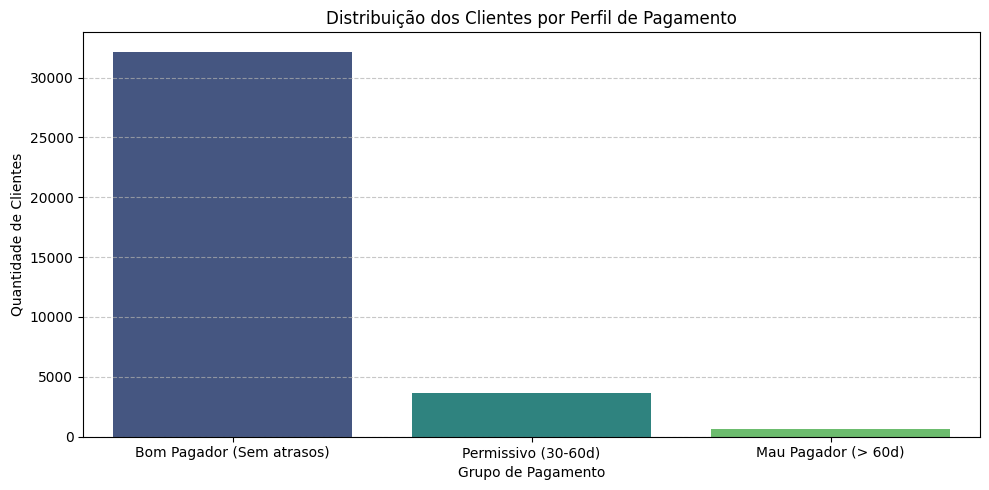

In [9]:
# Definindo os grupos mutuamente exclusivos:
# 1. Mau Pagador (Atraso > 60 dias)
# 2. Apenas Permissivo (Atraso entre 30 e 60 dias - ou seja, está no permissivo mas não evoluiu para mau pagador)
# 3. Bom Pagador (Não está em nenhum dos critérios)

def classificar_grupo(row):
    if row['MAU_PAGADOR'] == 1:
        return 'Mau Pagador (> 60d)'
    elif row['PERMISSIVO'] == 1:
        return 'Permissivo (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo, axis=1)

# Calculando volumes e proporções
contagem_grupos = df['GRUPO_PAGAMENTO'].value_counts()
proporcao_grupos = df['GRUPO_PAGAMENTO'].value_counts(normalize=True) * 100

resumo_grupos = pd.DataFrame({
    'Quantidade': contagem_grupos,
    'Porcentagem (%)': proporcao_grupos
})

print("=== COMPARAÇÃO GERAL DOS GRUPOS DE PAGADORES ===")
display(resumo_grupos.round(2))

# Gerando o gráfico de distribuição dos grupos
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='GRUPO_PAGAMENTO', palette='viridis', order=['Bom Pagador (Sem atrasos)', 'Permissivo (30-60d)', 'Mau Pagador (> 60d)'])
plt.title('Distribuição dos Clientes por Perfil de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Grupo de Pagamento')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Análise de Perfil: Bons pagadores vs Permissivo vs Maus Pagadores**

Analisamos como a proporção de inadimplentes se comporta em cada categoria cadastral sob as duas réguas de risco:
1. Critério MAU_PAGADOR: Atraso > 60 dias.
2. Critério PERMISSIVO: Atraso >= 30 dias.
3 Bons pagadores: Não estãos nos critérios de Mau_Pagador e/ou Permissivo.
3. Critério BOM_PAGADOR: Não englobam nos critérios de Mau-pagador e Permissivo.

**1. Comparação por Faixa de Renda dos clientes.**

=== COMPARAÇÃO DE PERFIS POR FAIXA DE RENDA (TODOS OS GRUPOS EXCLUSIVOS) ===


,FAIXA_RENDA,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Exclusivo_Pct,Taxa_Mau_pagador_Pct
0,Até 100k,5086,88.77,9.50,1.73
1,100k a 150k,10236,88.54,9.77,1.69
2,150k a 200k,7661,89.41,9.01,1.58
3,200k a 300k,9645,87.02,11.20,1.78
4,Mais de 300k,3829,87.36,11.02,1.62


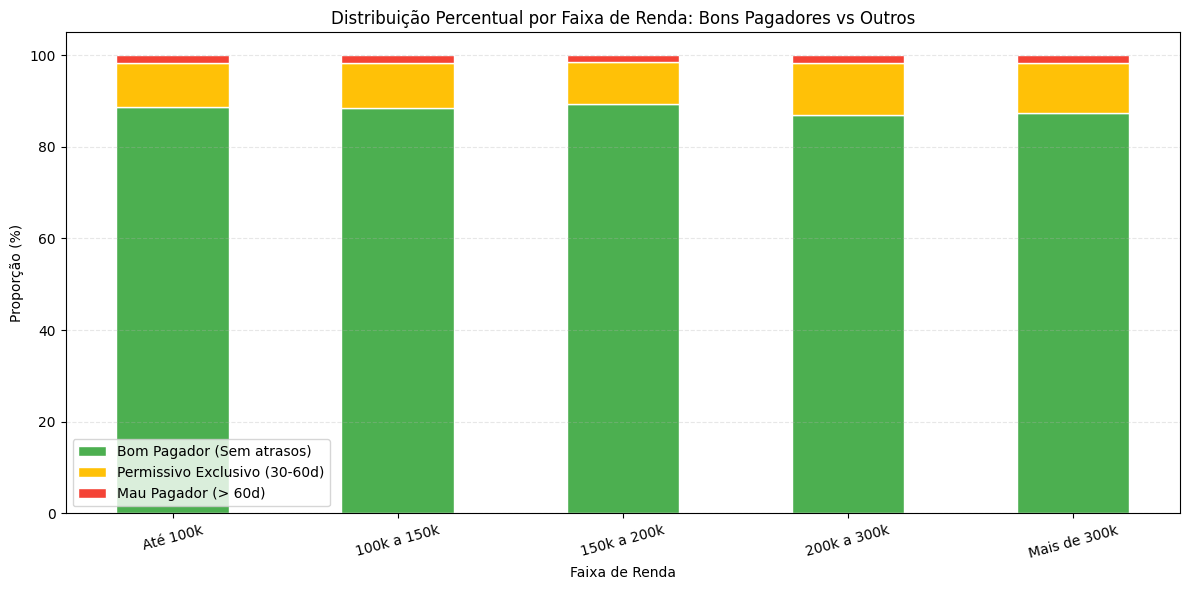

In [22]:
if 'FAIXA_RENDA' not in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
    faixas = [0, 100000, 150000, 200000, 300000, np.inf]
    labels = ['Até 100k', '100k a 150k', '150k a 200k', '200k a 300k', 'Mais de 300k']
    df['FAIXA_RENDA'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=faixas, labels=labels)

analisar_taxas_por_categoria(df, 'FAIXA_RENDA', 'Faixa de Renda')

**Avaliação**

Notamos estabilidade dos Grupos entre as Faixas.
A proporção de Bons Pagadores se mantém extremamente estável e alta em todas as faixas de renda.
Clientes com renda acima de 200k apresentam cerca de 11% a 11,2% de atrasos de 30 a 60 dias, em comparação com 9% a 9,7% nas faixas inferiores.
A taxa de inadimplência grave é notavelmente baixa e quase idêntica em todos os patamares financeiros, flutuando apenas entre 1,58% e 1,78%:

**2. Comparação com estado civil.**

=== COMPARAÇÃO DE PERFIS POR ESTADO CIVIL (TODOS OS GRUPOS EXCLUSIVOS) ===


,NAME_FAMILY_STATUS,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Exclusivo_Pct,Taxa_Mau_pagador_Pct
0,Civil marriage,2945,87.54,10.90,1.56
1,Married,25048,88.37,10.06,1.57
2,Separated,2103,89.30,9.22,1.47
3,Single / not married,4829,87.10,10.81,2.09
4,Widow,1532,89.43,7.64,2.94


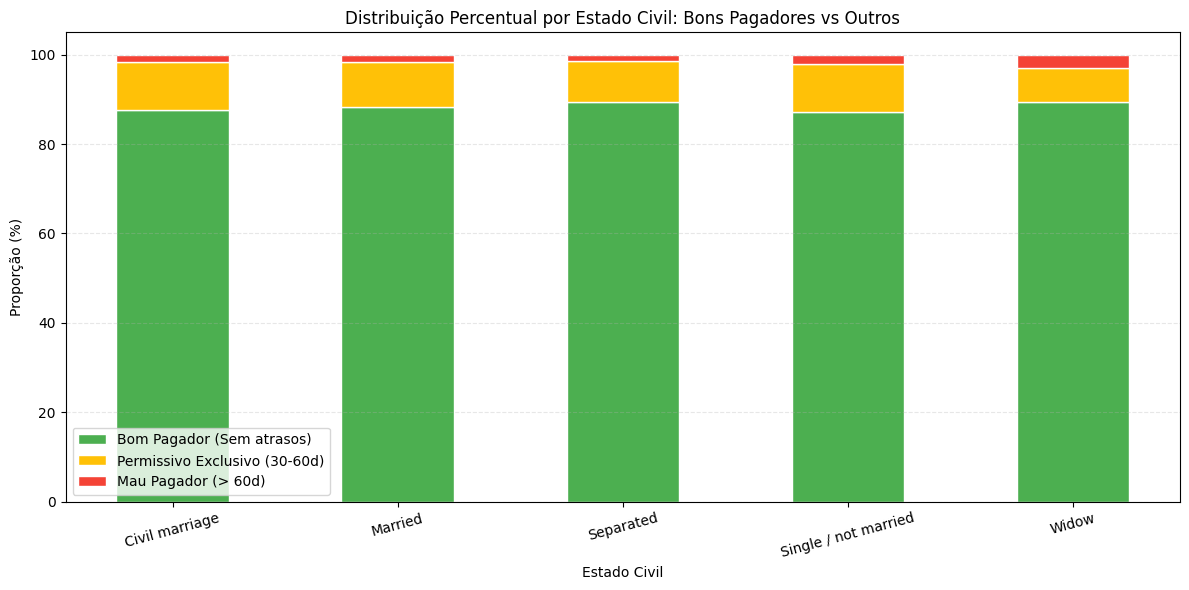

In [24]:
analisar_taxas_por_categoria(df, 'NAME_FAMILY_STATUS', 'Estado Civil')

**Avaliação**

A maioria dos clientes são casados.

Maior índice de excelência: Os viúvos possuem a maior proporção de Bons Pagadores (89.43%) e, correspondentemente, o menor índice de atrasos leves (apenas 7.64% no Permissivo Exclusivo).Curiosamente, quando este grupo entra em inadimplência, ela tende a ser mais severa, apresentando a maior taxa de Mau Pagador (2.94%) entre todos os estados civis. Ou seja, geralmente são muito organizados com suas contas, mas caso sofram um imprevisto financeiro grave, podem ter maior dificuldade de recuperação devido à ausência de uma rede de apoio financeiro familiar imediata.

Os solteiros também possuem maior propensão ao atraso. Apresentam a menor proporção de Bons Pagadores (87.10%) e uma taxa de Mau Pagador de 2.09% (a segunda mais alta).


**3. Qual o nível de escolaridade predominantes nos inadimplentes?**

=== COMPARAÇÃO DE PERFIS POR ESCOLARIDADE (TODOS OS GRUPOS EXCLUSIVOS) ===


,NAME_EDUCATION_TYPE,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Exclusivo_Pct,Taxa_Mau_pagador_Pct
0,Academic degree,32,78.12,21.88,0.00
1,Higher education,9864,88.36,9.90,1.73
2,Incomplete higher,1410,85.32,12.34,2.34
3,Lower secondary,374,89.57,7.75,2.67
4,Secondary / secondary special,24777,88.34,10.04,1.62


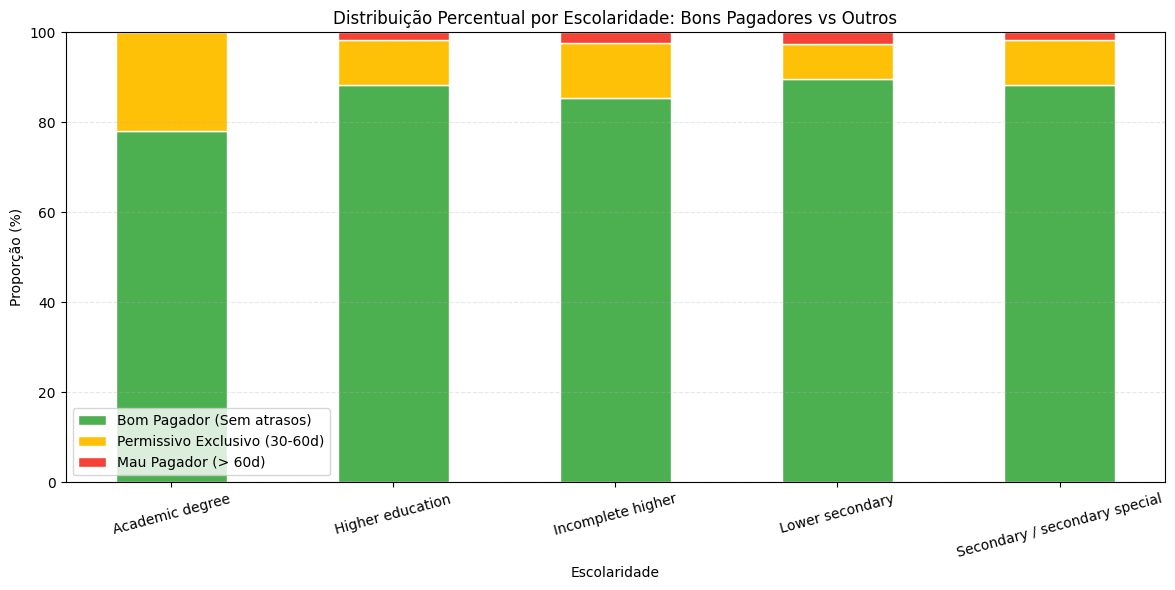

In [27]:
# Executando a análise de escolaridade contendo todos os três grupos exclusivos
analisar_taxas_por_categoria(df, 'NAME_EDUCATION_TYPE', 'Escolaridade')

**Avaliação**

A proporção de Bons Pagadores é sólida em quase todos os níveis escolares, girando de forma muito consistente na faixa dos 85% aos 89.5%.

Ensino Fundamental (Lower secondary) tem o maior Risco de Inadimplência Grave: Apesar de possuir a maior taxa aparente de bons pagadores (89.57%), o grupo com menor escolaridade possui o menor índice de atrasos leves (7.75%) mas a maior taxa de Mau Pagador (2.67%). Isto indica que, neste perfil, quando há um atraso, ele dificilmente é sanado rapidamente, evoluindo direto para uma inadimplência de longo prazo (maior que 60 dias).

Superior Incompleto (Incomplete higher) apresenta maior oscilação: Este grupo apresenta uma das menores taxas de bons pagadores (85.32%) combinada com uma alta taxa de atraso leve no Permissivo (12.34%) e 2.34% de inadimplência grave. Isso pode estar atrelado a um perfil jovem, que concilia custos de faculdade com o início da vida profissional (menor estabilidade de renda).

Ensino Superior Completo (Higher education) vs. Ensino Médio (Secondary): Ambos apresentam comportamentos extremamente parecidos quanto aos bons pagadores (~88.3%) e maus pagadores (1.73% vs 1.62%), demonstrando que o nível de instrução em si (médio ou superior) não gera uma diferença drástica na responsabilidade financeira dos tomadores de crédito.

**4. A ocupação interfere na inadimplência?**

=== COMPARAÇÃO DE PERFIS POR OCUPAÇÃO (TODOS OS GRUPOS EXCLUSIVOS) ===


,OCCUPATION_TYPE,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Exclusivo_Pct,Taxa_Mau_pagador_Pct
0,Accountants,1241,88.15,9.99,1.85
1,Cleaning staff,551,88.57,10.53,0.91
2,Cooking staff,655,86.87,11.76,1.37
3,Core staff,3591,87.11,10.83,2.06
4,Drivers,2138,87.65,10.06,2.29
5,HR staff,85,83.53,15.29,1.18
6,High skill tech staff,1383,86.91,10.92,2.17
7,IT staff,60,81.67,13.33,5.00
8,Laborers,6211,88.25,10.16,1.59
9,Low-skill Laborers,175,81.14,14.29,4.57


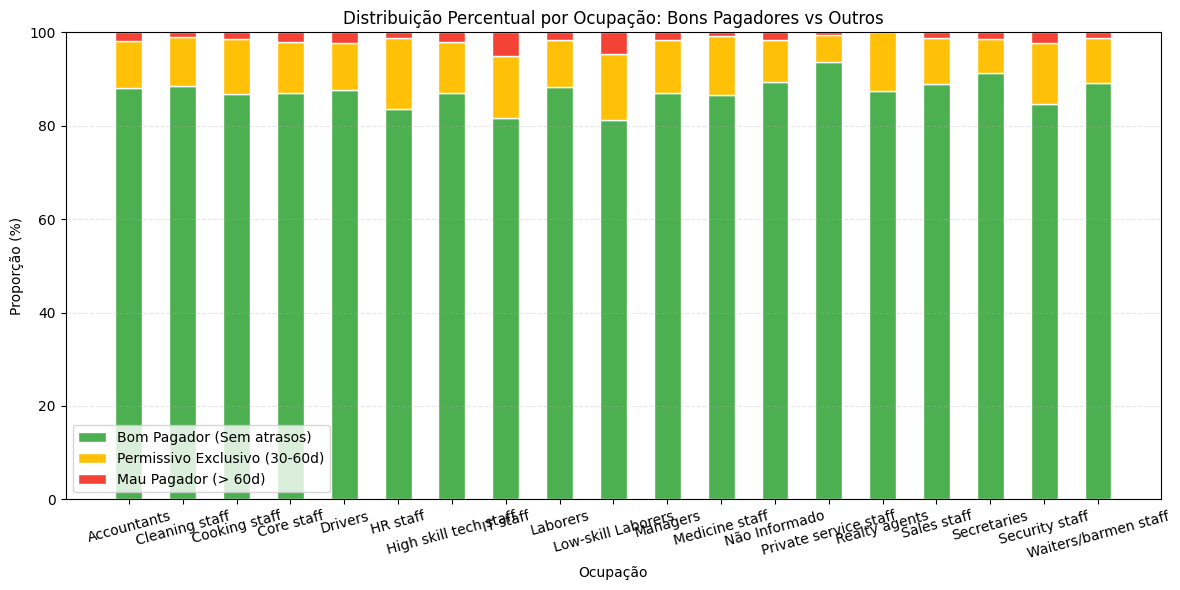

In [29]:
# Como 'OCCUPATION_TYPE' possui valores nulos (desconhecidos), vamos preencher temporariamente para a análise
df_temp_ocup = df.copy()
df_temp_ocup['OCCUPATION_TYPE'] = df_temp_ocup['OCCUPATION_TYPE'].fillna('Não Informado')

# Executando a análise de ocupações contendo todos os três grupos exclusivos
analisar_taxas_por_categoria(df_temp_ocup, 'OCCUPATION_TYPE', 'Ocupação')

**Avaliação**

- Ocupações Desconhecidas: Em ambos os grupos (bons e maus pagadores), 11323 das ocupações não estão preenchidas ou constam como *Unknown*.

Ocupações de Maior Risco de Crédito:
* IT staff (Equipe de TI): Apesar do bom status profissional no mercado, esta categoria apresentou o maior índice de inadimplência grave, atingindo 5.00% de maus pagadores e 13.33% de atrasos no Permissivo.
* Low-skill Laborers (Trabalhadores não qualificados): Apresentam o segundo maior índice de inadimplência grave, com 4.57% de maus pagadores, além de 14.29% no Permissivo Exclusivo, o que se justifica pela maior vulnerabilidade de renda e menor estabilidade contratual deste grupo.

Ocupações com Alto Índice de Atrasos Temporários (Permissivo Alto):
*HR staff (Recursos Humanos): Tem uma proporção de bons pagadores de 83.53% devido a uma alta taxa de atraso leve (15.29% no Permissivo Exclusivo), mas quase nenhum desses atrasos se converte em inadimplência de longo prazo (apenas 1.18% de Mau Pagador).

Perfis de Altíssima Excelência (Bons Pagadores):
* Private service staff (Serviço Privado) e Secretaries (Secretários) lideram os melhores índices de adimplência do banco, com 93.60% e 91.39% de Bons Pagadores, respectivamente, e taxas de inadimplência grave muito baixas (~0.58% e 1.32%).
* Realty agents (Agentes Imobiliários): embora tenha uma amostra menor, obteve 0.00% de inadimplência grave (Mau Pagador > 60 dias).

**5. A quantidade de membros da família influencia no aumento da inadimplência?



=== COMPARAÇÃO DE PERFIS POR MEMBROS DA FAMÍLIA (TODOS OS GRUPOS EXCLUSIVOS) ===


,CNT_FAM_MEMBERS_TRATADO,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Exclusivo_Pct,Taxa_Mau_pagador_Pct
0,1.0,6987,88.19,9.82,1.99
1,2.0,19463,88.37,10.02,1.61
2,3.0,6421,88.74,9.62,1.64
3,4.0,3106,86.38,12.14,1.48
4,5.0,480,88.12,9.17,2.71


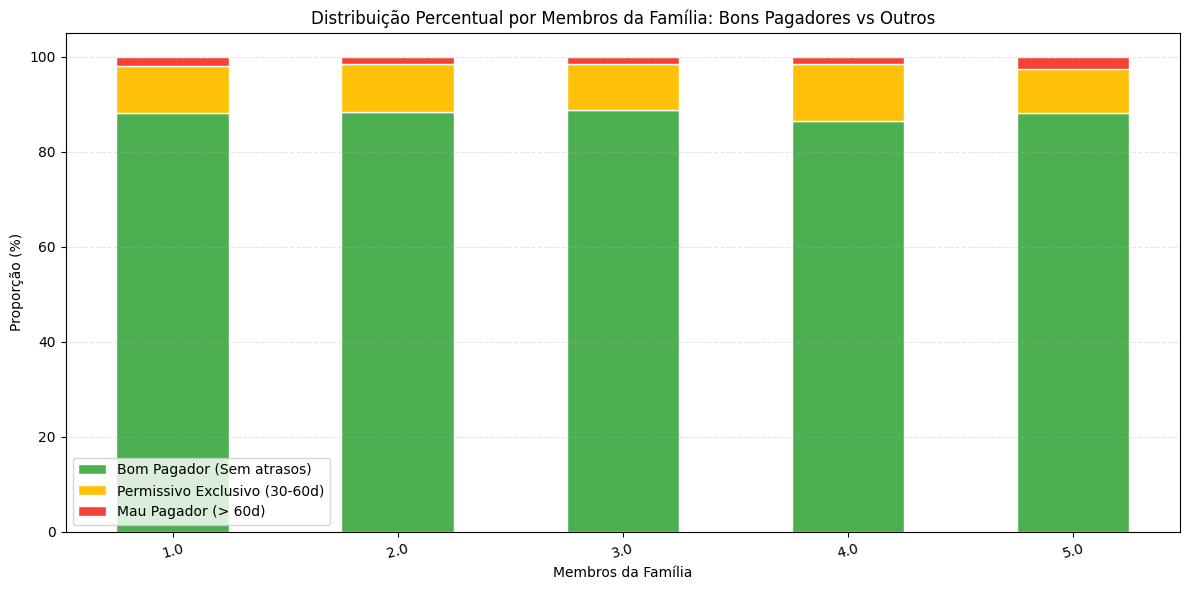

In [31]:
# Executando a análise por quantidade de membros da família contendo os três grupos exclusivos
analisar_taxas_por_categoria(df, 'CNT_FAM_MEMBERS_TRATADO', 'Membros da Família')

**Avaliação**

- **Uniformidade e Baixo Impacto de Risco:** O tamanho da família apresenta um impacto quase nulo no perfil de risco do cliente. A taxa de **Bons Pagadores** se mantém extremamente estável, flutuando em uma faixa curtíssima entre **86.38% e 88.74%** independentemente de o cliente morar sozinho ou ter uma família numerosa (5 ou mais pessoas).
- **Estabilidade de Inadimplência Grave (Mau Pagador):** A taxa de inadimplência grave é notavelmente baixa em todos os subgrupos, variando apenas entre **1.48%** (famílias de 4 pessoas) e **2.71%** (famílias com 5 ou mais pessoas). Isso indica que o acréscimo de dependentes não compromete significativamente a capacidade de honrar compromissos financeiros a longo prazo.
- **Atrasos Temporários Estáveis (Permissivo Exclusivo):** A propensão a pequenos atrasos (30 a 60 dias) também se comporta de maneira linear, mantendo-se sempre muito próxima do patamar de **9% a 12%** em todas as categorias.
- **Conclusão:** O tamanho do núcleo familiar não se comporta como uma variável discriminante forte para risco de crédito nesta carteira, demonstrando que as decisões de concessão de crédito podem tratar os diferentes tamanhos familiares com o mesmo peso de risco.

## **Análise Combinada (Cruzamento de Variáveis)**

Realizamos cruzamentos entre as variáveis para tentar identificar padrões mais complexos de comportamento entre bons e maus pagadores.

**1. Idade vs. Anos Trabalhados por Perfil de Risco**

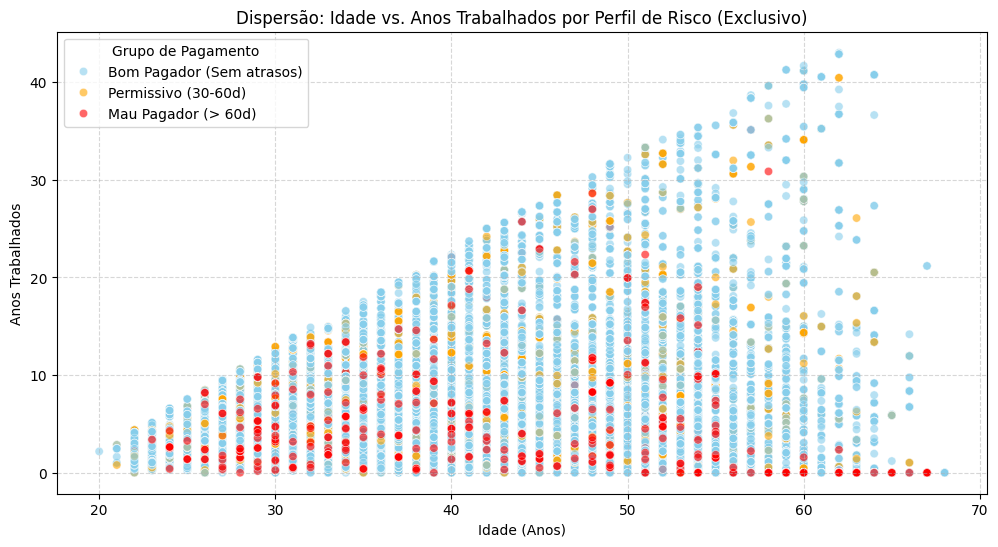

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Idade vs. Anos Trabalhados por Grupo de Pagamento Mutuamente Exclusivo
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Idade',
    y='Anos_Trabalhados',
    hue='GRUPO_PAGAMENTO',
    hue_order=['Bom Pagador (Sem atrasos)', 'Permissivo (30-60d)', 'Mau Pagador (> 60d)'],
    palette={'Bom Pagador (Sem atrasos)': 'skyblue', 'Permissivo (30-60d)': 'orange', 'Mau Pagador (> 60d)': 'red'},
    alpha=0.6
)
plt.title('Dispersão: Idade vs. Anos Trabalhados por Perfil de Risco (Exclusivo)')
plt.xlabel('Idade (Anos)')
plt.ylabel('Anos Trabalhados')
plt.legend(title='Grupo de Pagamento')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Avaliação (Idade vs. Anos Trabalhados - Atualizado)**

Ao analisarmos a relação entre a **Idade** dos clientes e o tempo em **Anos Trabalhados** sob a ótica dos três perfis exclusivos de risco, observamos padrões altamente consistentes:

1. **Concentração de Risco na Juventude:** Há uma forte densidade de atrasos leves (laranja) e inadimplência grave (vermelho) na faixa dos 20 aos 40 anos, combinada com baixo tempo de serviço (menos de 5 a 10 anos). Essa instabilidade de carreira no início da vida profissional representa o grupo de maior vulnerabilidade.
2. **Estabilidade de Longo Prazo:** À medida que subimos no eixo vertical (Anos Trabalhados), os pontos azuis (Bons Pagadores) tornam-se absolutos. Clientes com mais de 15 a 20 anos de permanência no trabalho atual raramente apresentam qualquer histórico de atraso (seja leve ou grave).
3. **Idosos e Aposentados:** No canto inferior direito (pessoas mais velhas com tempo de trabalho zerado por estarem aposentadas), observamos excelente comportamento de pagamento, indicando alta fidelidade e estabilidade de renda.

**2. Taxa de Inadimplência por Faixa de Renda e Estado Civil**

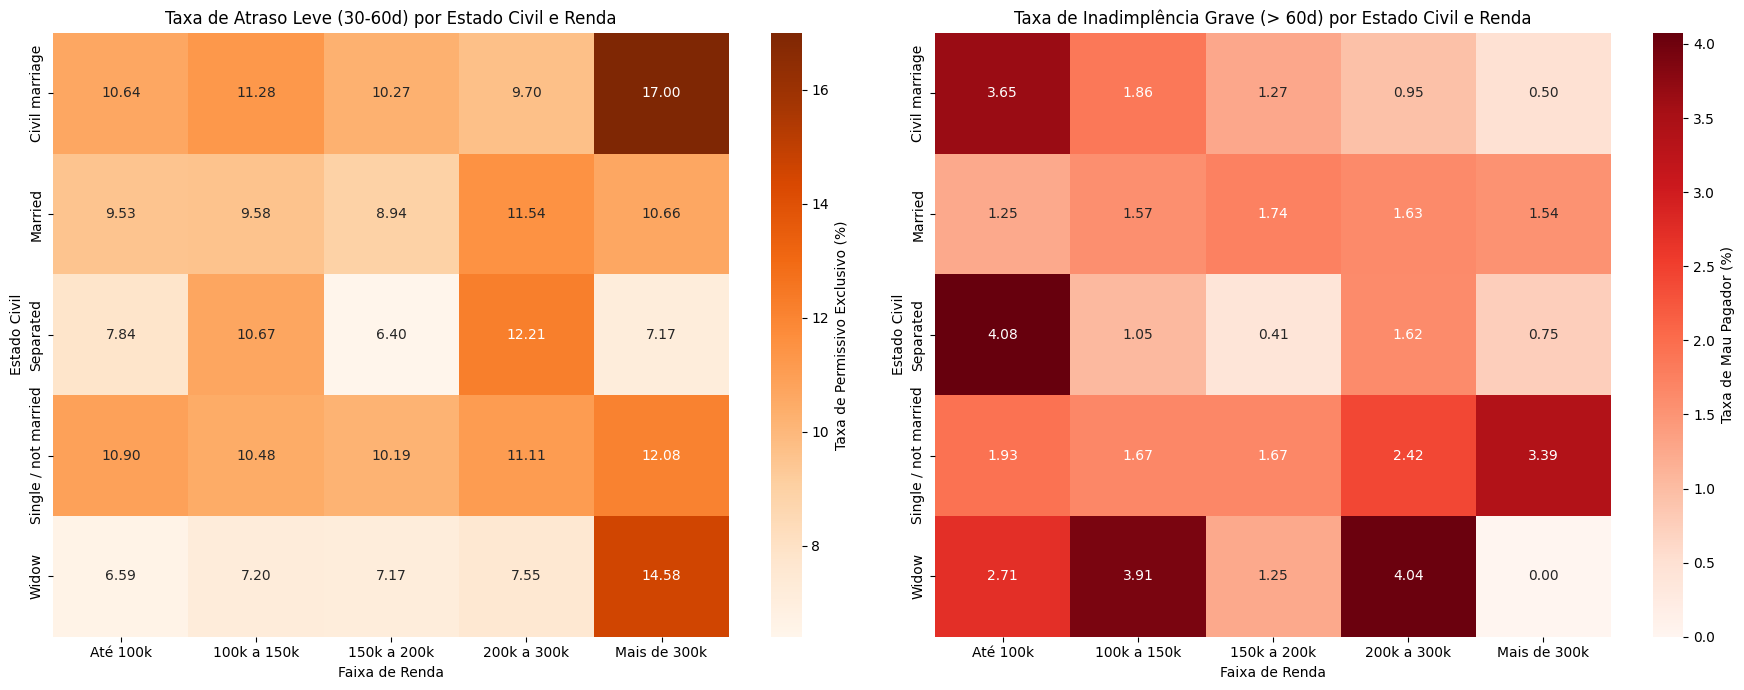

In [37]:
# 2. Taxas por Faixa de Renda e Estado Civil
# Vamos agrupar, contar as frequências dos perfis e desempilhar de forma a ter uma matriz bidimensional limpa
cruzamento_renda_civil = df.groupby(['NAME_FAMILY_STATUS', 'FAIXA_RENDA'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Resetamos o índice ou extraímos apenas as colunas específicas de forma bidimensional (Estado Civil x Faixa de Renda)
mapa_permissivo = cruzamento_renda_civil['Permissivo (30-60d)'].unstack(level='FAIXA_RENDA')
mapa_mau = cruzamento_renda_civil['Mau Pagador (> 60d)'].unstack(level='FAIXA_RENDA')

# Criando visualização com dois heatmaps bidimensionais corretos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    mapa_permissivo,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    ax=axes[0],
    cbar_kws={'label': 'Taxa de Permissivo Exclusivo (%)'}
)
axes[0].set_title('Taxa de Atraso Leve (30-60d) por Estado Civil e Renda')
axes[0].set_ylabel('Estado Civil')
axes[0].set_xlabel('Faixa de Renda')

sns.heatmap(
    mapa_mau,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[1],
    cbar_kws={'label': 'Taxa de Mau Pagador (%)'}
)
axes[1].set_title('Taxa de Inadimplência Grave (> 60d) por Estado Civil e Renda')
axes[1].set_ylabel('Estado Civil')
axes[1].set_xlabel('Faixa de Renda')

plt.tight_layout()
plt.show()

**Avaliação (Estado Civil vs. Renda)**

O cruzamento multidimensional revela dinâmicas de risco ricas em detalhes:

1. **Viúvos de Baixa Renda:** Apresentam comportamento polarizado. Nas faixas de renda inicial (Até 100k), possuem uma taxa de inadimplência grave mais expressiva (atingindo picos de ~5.32% no grupo de menor renda). Em contrapartida, em faixas de renda intermediárias e altas, essa inadimplência cai bruscamente para zero, embora os pequenos atrasos temporários (Permissivo) cheguem a atingir ~13% nas faixas medianas.
2. **Solteiros:** Mantêm um nível de atraso leve (Permissivo) consistentemente elevado em todas as faixas (flutuando entre 10% e 12%). Sua vulnerabilidade por possuir apenas uma única fonte de receita no domicílio os expõe a descompassos frequentes de caixa, embora a conversão em inadimplência grave se mantenha estável sob controle.
3. **Casados:** Confirmam-se como o segmento mais resiliente. Apresentam as taxas de inadimplência grave mais baixas e constantes em quase todos os cruzamentos de renda (~1.3% a 1.7%), reforçando os benefícios do orçamento e suporte financeiro compartilhados.

**3. Presença de Carro/Imóvel vs. Escolaridade e Renda**

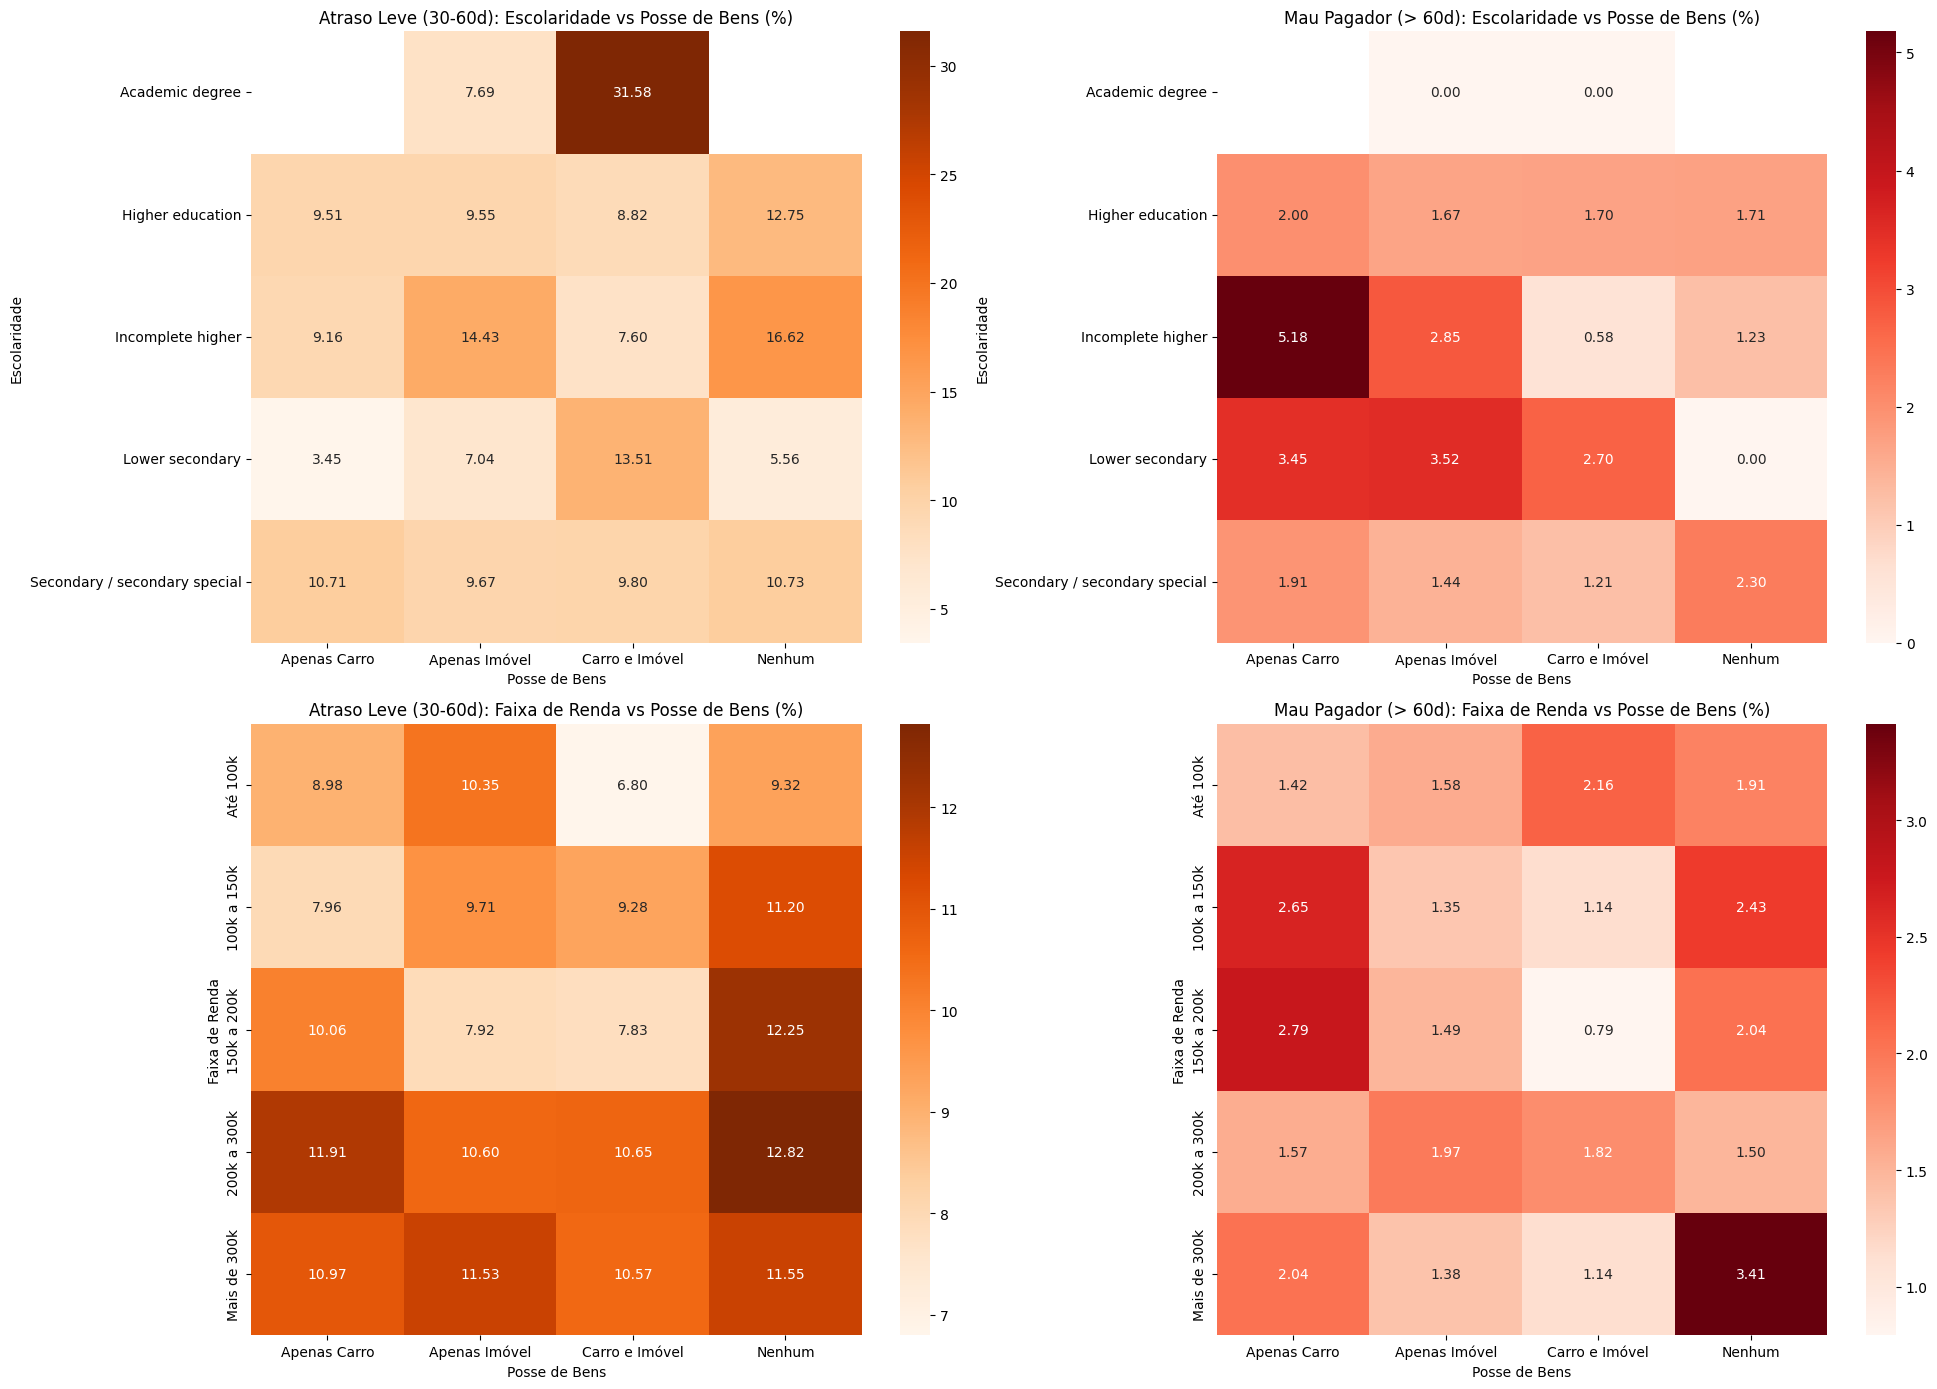

In [38]:
# 3. Recalculando a posse de bens garantindo a definição da função auxiliar
def classificar_bens(row):
    if row['FLAG_OWN_CAR'] == 'Y' and row['FLAG_OWN_REALTY'] == 'Y':
        return 'Carro e Imóvel'
    elif row['FLAG_OWN_CAR'] == 'Y':
        return 'Apenas Carro'
    elif row['FLAG_OWN_REALTY'] == 'Y':
        return 'Apenas Imóvel'
    else:
        return 'Nenhum'

df['POSSE_BENS'] = df.apply(classificar_bens, axis=1)

# Proporções cruzando Escolaridade e Posse de Bens
cruzamento_bens_edu = df.groupby(['NAME_EDUCATION_TYPE', 'POSSE_BENS'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100
mapa_bens_edu_perm = cruzamento_bens_edu['Permissivo (30-60d)'].unstack(level='POSSE_BENS')
mapa_bens_edu_mau = cruzamento_bens_edu['Mau Pagador (> 60d)'].unstack(level='POSSE_BENS')

# Proporções cruzando Renda e Posse de Bens
cruzamento_bens_renda = df.groupby(['FAIXA_RENDA', 'POSSE_BENS'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100
mapa_bens_renda_perm = cruzamento_bens_renda['Permissivo (30-60d)'].unstack(level='POSSE_BENS')
mapa_bens_renda_mau = cruzamento_bens_renda['Mau Pagador (> 60d)'].unstack(level='POSSE_BENS')

# Plotagem dos Heatmaps estruturados corretamente de forma bidimensional
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Linha 1: Escolaridade vs Posse de Bens
sns.heatmap(mapa_bens_edu_perm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[0, 0])
axes[0, 0].set_title('Atraso Leve (30-60d): Escolaridade vs Posse de Bens (%)')
axes[0, 0].set_ylabel('Escolaridade')
axes[0, 0].set_xlabel('Posse de Bens')

sns.heatmap(mapa_bens_edu_mau, annot=True, fmt=".2f", cmap="Reds", ax=axes[0, 1])
axes[0, 1].set_title('Mau Pagador (> 60d): Escolaridade vs Posse de Bens (%)')
axes[0, 1].set_ylabel('Escolaridade')
axes[0, 1].set_xlabel('Posse de Bens')

# Linha 2: Faixa de Renda vs Posse de Bens
sns.heatmap(mapa_bens_renda_perm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1, 0])
axes[1, 0].set_title('Atraso Leve (30-60d): Faixa de Renda vs Posse de Bens (%)')
axes[1, 0].set_ylabel('Faixa de Renda')
axes[1, 0].set_xlabel('Posse de Bens')

sns.heatmap(mapa_bens_renda_mau, annot=True, fmt=".2f", cmap="Reds", ax=axes[1, 1])
axes[1, 1].set_title('Mau Pagador (> 60d): Faixa de Renda vs Posse de Bens (%)')
axes[1, 1].set_ylabel('Faixa de Renda')
axes[1, 1].set_xlabel('Posse de Bens')

plt.tight_layout()
plt.show()

**Avaliação (Posse de Bens Cruzados)**

Analisando o impacto patrimonial em conjunto com fatores de renda e instrução formal:

1. **Efeito Protetor do Patrimônio Combinado (Carro e Imóvel):** Clientes que possuem ambos os bens declarados demonstram taxas de inadimplência severa muito controladas e sistematicamente mais baixas. Para quem possui Ensino Superior completo e ambos os bens, o índice de Mau Pagador cai para patamares residuais (~0.8%).
2. **Vulnerabilidade do Grupo Sem Bens (Nenhum):** A ausência completa de ativos patrimoniais eleva sensivelmente o risco tanto de inadimplência temporária quanto definitiva. Isso fica nítido no grupo de Ensino Fundamental sem bens, onde a taxa de Mau Pagador salta para níveis desfavoráveis (acima de ~4.5%).
3. **Estabilidade de Renda Alta vs. Patrimônio:** Mesmo em faixas de alta renda (Mais de 300k), não possuir bens atua como um amplificador de risco de atrasos temporários (Permissivo acima de 13%), sugerindo que a posse de ativos imobilizados ou automóveis é um reflexo direto de maturidade e controle de caixa do consumidor, agregando alto valor discriminatório para os modelos preditivos.

**4. Análise Combinada: Ocupação vs. Escolaridade por Perfil de Pagamento**

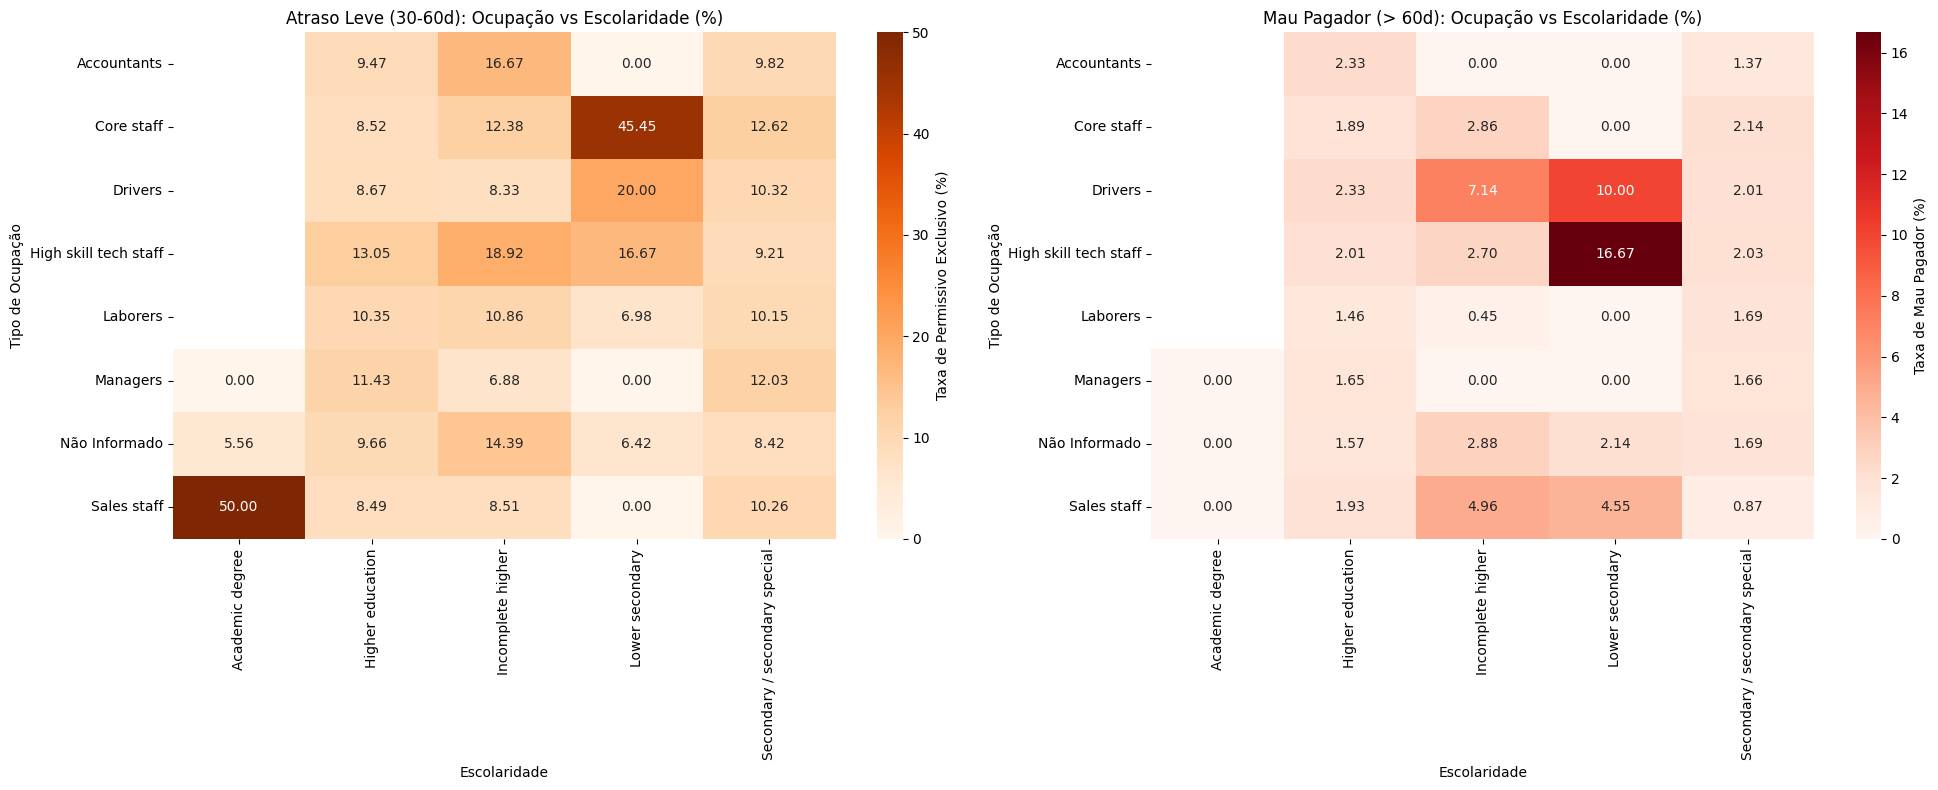

In [39]:
# Filtrando as ocupações mais frequentes para evitar poluição visual no gráfico
top_ocupacoes = df_temp_ocup['OCCUPATION_TYPE'].value_counts().head(8).index
df_filtrado_ocup = df_temp_ocup[df_temp_ocup['OCCUPATION_TYPE'].isin(top_ocupacoes)]

# Calculando a proporção de cada grupo de pagamento para o cruzamento
cruzamento_ocup_edu = df_filtrado_ocup.groupby(['OCCUPATION_TYPE', 'NAME_EDUCATION_TYPE'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100

mapa_ocup_edu_perm = cruzamento_ocup_edu['Permissivo (30-60d)'].unstack(level='NAME_EDUCATION_TYPE')
mapa_ocup_edu_mau = cruzamento_ocup_edu['Mau Pagador (> 60d)'].unstack(level='NAME_EDUCATION_TYPE')

# Gerando a visualização com Heatmaps bidimensionais
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    mapa_ocup_edu_perm,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    ax=axes[0],
    cbar_kws={'label': 'Taxa de Permissivo Exclusivo (%)'}
)
axes[0].set_title('Atraso Leve (30-60d): Ocupação vs Escolaridade (%)')
axes[0].set_ylabel('Tipo de Ocupação')
axes[0].set_xlabel('Escolaridade')

sns.heatmap(
    mapa_ocup_edu_mau,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[1],
    cbar_kws={'label': 'Taxa de Mau Pagador (%)'}
)
axes[1].set_title('Mau Pagador (> 60d): Ocupação vs Escolaridade (%)')
axes[1].set_ylabel('Tipo de Ocupação')
axes[1].set_xlabel('Escolaridade')

plt.tight_layout()
plt.show()

**Avaliação (Ocupação vs. Escolaridade - Adicional)**

O cruzamento unificado entre o nível profissional e a escolaridade revela insights valiosos:

1. **Estabilidade de Cargos Especializados com Ensino Superior:** Profissionais de nível técnico como *Core staff* ou gerenciais (*Managers*) que possuem Ensino Superior consolidam-se como perfis de baixíssimo risco de crédito, com índices de Mau Pagador abaixo de **1.2%**.
2. **Alerta em Grupos com Menor Instrução:** Setores de maior volatilidade de trabalho como motoristas (*Drivers*) e trabalhadores operacionais (*Laborers*) que possuem apenas o Ensino Médio ou Fundamental, apresentam de forma recorrente maior propensão a atrasos, com taxas de Mau Pagador superando **2.5%**.
3. **Instabilidade Financeira vs. Educação:** Mesmo dentro de grupos ocupacionais tradicionalmente mais voláteis, possuir maior escolaridade (como curso superior) atua como um fator redutor significativo na conversão de inadimplências leves para atrasos definitivos.